## Aurora_V4 - kW

#### <span style="color:red; font-weight:bold"> Instructions for Using this Jupyter Notebook:</span>
This Notebook is using the sum of kW/4 to calculate the kWh total usage within one fiscal year.

<span style="color:royalblue">(1) Place **data_clean.py** and this Notebook in the same folder (already done)</span>

<span style="color:royalblue">(2) Place **aurora_v4.meter_info.csv,** **building_complex_master_sheet_fyXX.xlsx** and the **raw data files** in the same directory (already done)</span> 
- **aurora_v4.meter_info.csv** is exported from the database
- Make sure there's a **building_complex_master_sheet_fyXX.xlsx** for that fiscal year and it contains the column **"use kWh or kW"**.
- **NOTE:** Filename of the raw data files should include the variable name (i.e., kw)

<span style="color:royalblue">(3) Modify the **Parameters in Section 1** as needed before running this Notebook:</span> 
- Directories, Filenames,
- Time range


### 1. Parameters

In [ ]:
############ CHANGE PARAMETERS AS NEEDED #############

Checked = True#False#   # Set to True after you checked the meter's kW plot below
Insert = True   # Make sure there's a building_complex_master_sheet_fyXX.xlsx for that fiscal year.
Insert_HECO = True   # Set to False if there's no HECO's annual kWh file for that fiscal year.

# Time Range: Select One Fiscal Year
start_time = "2024-07-01 00:00:00"
end_time = "2025-07-01 00:00:00"
FY = "_fy25"

# After checking the plot below, identify meters that need to be excluded
meters_excluded = ['bachman_hall_annex', 'bachman_hall_main', 'dance_bldg_main']

######################################################

In [2]:

# Data Directories
input_dir = '../data/extracts/'  # directory for raw data files & other input files

output_dir = '../data/outputs/'  # directory for data outputs (different from input_dir)

plot_dir = '../data/outputs/plots/'  # directory for plot outputs


# Variable
var = 'kw'


# Input Files
var_file = input_dir + "aurora_v4."+var+".fy22_fy25.csv"  # data file 0
var_rejects_file = input_dir + "aurora_v4."+var+"_rejects.fy22_fy25.csv"  # data file 1

meter_info_file = input_dir + "aurora_v4.meter_info.csv"

######################################################
if Insert:
    insert_sheet = input_dir + "building_complex_master_sheet" + FY + ".xlsx"  # insert output kWh usage into this sheet
    sheet_name = "complex"
    use_col = "use kWh or kW"
    target_col_idx = 10  # insert into column K "Net kWh"

if Insert_HECO:
    heco_file = input_dir + "heco_kwh" + FY + ".xlsx"  # Read from this heco_file and insert numbers into master sheet
    col_name = "kWh" + FY
######################################################

# Output Files (generated from kwh_end_points.ipynb -> insert numbers into these two files)
meter_annual_csv = output_dir + "meter_annual_kwh" + FY + ".csv"  # annual kwh usage for each meter
building_annual_csv = output_dir + "building_annual_kwh" + FY + ".csv"  # annual kwh usage for each building


# Data Frequency
freq = '15min'

# Schema
schema = 'aurora_v4'


### 2. Imports

In [3]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from openpyxl import load_workbook
from openpyxl.styles import Alignment
import math

import data_clean as dc  # import self-defined module


### 3. Load Data

In [4]:
# Read var and var_rejects tables
df0 = pd.read_csv(var_file)
df1 = pd.read_csv(var_rejects_file)


In [5]:
# Use the "use kWh or kW" column in Master Sheet

if Insert:
    
    # Read Master Sheet Excel and Meter Info CSV
    master_df = pd.read_excel(insert_sheet, skiprows=1)
    meter_info_df = pd.read_csv(meter_info_file)
    
    # Ensure building_complex_id is string in both DataFrames
    master_df["building_complex_id"] = master_df["building_complex_id"].astype(str)
    meter_info_df["building_complex_id"] = meter_info_df["building_complex_id"].astype(str)
    
    # Step 1: Filter rows where use kWh or kW == var (case-insensitive)
    master_df_var = master_df[master_df[use_col].str.lower() == var.lower()]
    
    # Step 2: Get building IDs for this var
    var_ids = master_df_var["building_complex_id"]
    
    # Step 3: Get meter names linked to those IDs
    var_meters = meter_info_df.loc[meter_info_df["building_complex_id"].isin(var_ids), "meter_name"].unique()
    
    # Step 4: Filter df0 and df1 to retain only the var_meters
    df0_var = df0[df0["meter_name"].isin(var_meters)].copy()
    df1_var = df1[df1["meter_name"].isin(var_meters)].copy()
    
    # Meters that use sum of kW/4 to calculate annual kWh usage
    var_meters


### 4. Data Processing

In [6]:
# Concatenate df0 and df1 vertically
combined_df = pd.concat([df0_var, df1_var], ignore_index=True)

# Convert 'datetime' to datetime type (if not already)
combined_df['datetime'] = pd.to_datetime(combined_df['datetime'])

# Sort by meter_name and datetime
combined_df = combined_df.sort_values(by=['meter_name', 'datetime']).reset_index(drop=True)


In [7]:
# Pivot table with every meter be one column
pivoted_df = combined_df.pivot(index='datetime', columns='meter_name', values='mean').reset_index()

# Fill missing timestamps
full_df = dc.fill_missing_timestamps(pivoted_df, freq).set_index("datetime")
full_df.head(2)


,bachman_hall_annex,bachman_hall_main,dance_bldg_main,frog_1,frog_2,gartley_hall_main
datetime,,,,,,
2021-07-01 00:00:00,NaN,75.0,3.747990,0.69,1.00,5.823025
2021-07-01 00:15:00,NaN,NaN,3.989113,0.69,1.01,5.680971


##### <span style="color:royalblue">Filter Time Range:</span>

In [8]:
### Retain only the most recent Fiscal Year Data ###

data = full_df.loc[start_time:end_time, :].copy()
data.index = pd.to_datetime(data.index)

# Replace all 0s with NaN in the entire DataFrame - Data Cleaning
data = data.replace(0, np.nan)


##### <span style="color:royalblue">Plot All Meters:</span>

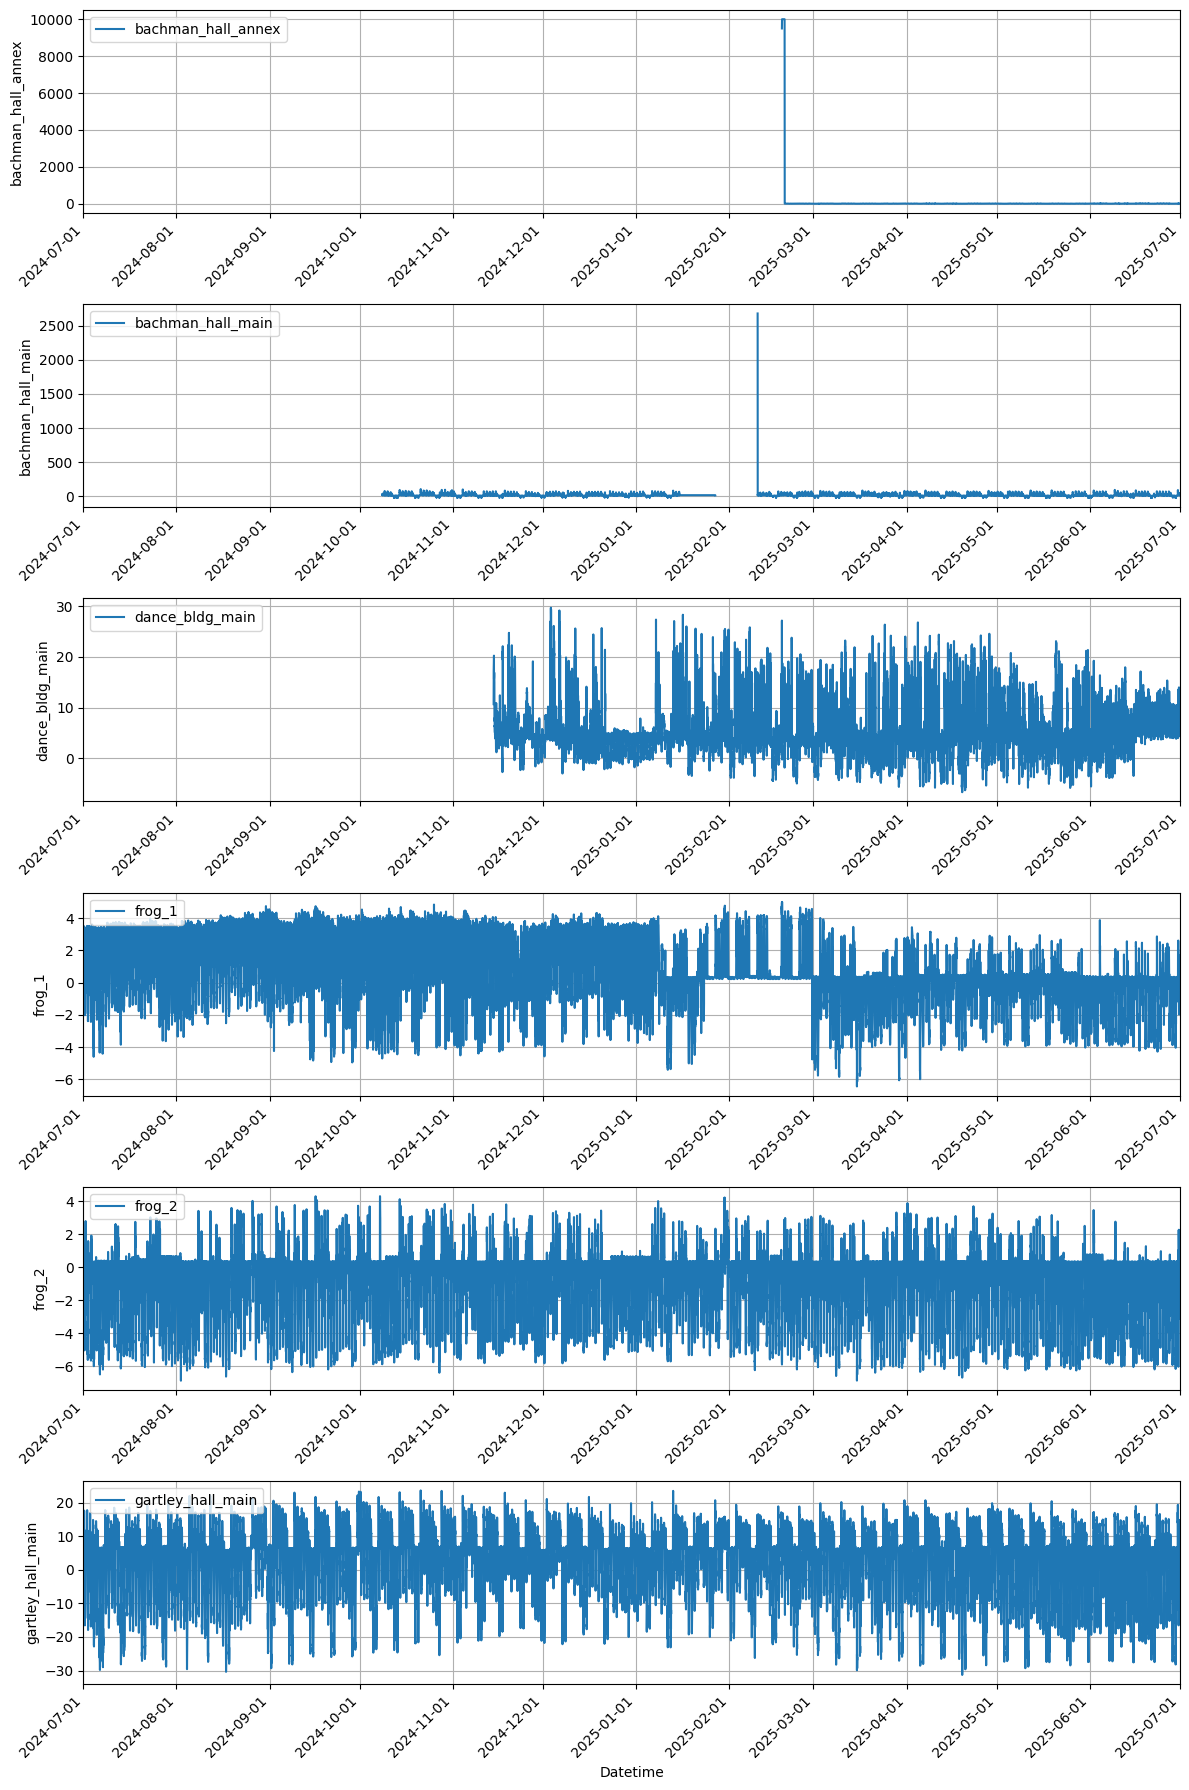

In [9]:
dc.plot_kw_meters(data)


<Axes: xlabel='datetime'>

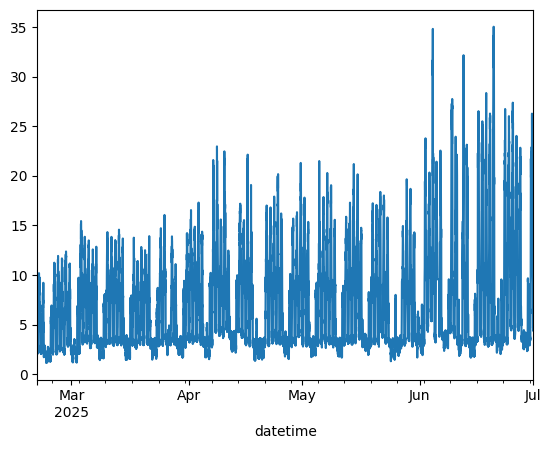

In [10]:
data.loc["2025-02-20":, "bachman_hall_annex"].plot()

In [11]:
if not Checked:
    raise SystemExit("Execution stopped because Checked = False")


### 5. Calculate Sum of kW/4

In [12]:
# Identify columns to exclude
cols_excluded = [col for col in data.columns if any(meter in col for meter in meters_excluded)]

# Keep only the remaining columns
data_filtered = data[[col for col in data.columns if col not in cols_excluded]]

data_filtered


,frog_1,frog_2,gartley_hall_main
datetime,,,
2024-07-01 00:00:00,3.197796,0.355119,6.642964
2024-07-01 00:15:00,1.619019,0.355257,6.522194
2024-07-01 00:30:00,1.104480,0.355387,6.561092
2024-07-01 00:45:00,1.139148,0.356491,6.356307
2024-07-01 01:00:00,3.379616,0.355442,6.376605
...,...,...,...
2025-06-30 23:00:00,0.369972,0.362203,6.947099
2025-06-30 23:15:00,0.369043,0.358838,6.759317
2025-06-30 23:30:00,0.371604,0.387718,6.942428


In [13]:
# Copy the data and drop the last row (For FY25: 2025-07-01 00:00:00)
df = data_filtered.iloc[:-1]

# Total number of intervals (excluding last row)
total_intervals = len(df)

# Function to compute scaled kWh for one meter
def compute_kwh(series):
    valid_count = series.count()        # number of non-null points
    sum_kw = series.sum()               # sum of available kW values
    # scale to account for missing values
    scaled_sum_kw = sum_kw / valid_count * total_intervals if valid_count > 0 else 0
    # convert to kWh
    return scaled_sum_kw / 4

# Apply to all columns
fy_kwh = df.apply(compute_kwh)

print("FY" + FY + " total kWh for each meter:")
print(fy_kwh)


FY_fy25 total kWh for each meter:
frog_1                6324.930304
frog_2               -5375.905185
gartley_hall_main    30594.460776
dtype: float64


##### <span style="color:royalblue">Insert data into master_sheet:</span>

In [14]:
# Map meter_name → building_complex_name
meter_to_bldg = meter_info_df.set_index('meter_name')['building_complex_name']

# Build building-level kWh Series
bldg_kwh = fy_kwh.copy()
bldg_kwh.index = bldg_kwh.index.map(lambda x: meter_to_bldg.get(x))  # map to building
bldg_kwh = bldg_kwh.dropna()  # remove meters without building
bldg_kwh = bldg_kwh.groupby(bldg_kwh.index).sum()  # sum if multiple meters for one building

# Insert values into Master Sheet
if Insert:

    # Load workbook and sheet
    wb = load_workbook(insert_sheet)
    ws = wb[sheet_name]

    # Insert values row by row
    # Data starts from row 3 (2-row header)
    for row in ws.iter_rows(min_row=3):
        # building_complex_name is in column C (index 2)
        bldg_name = str(row[2].value).strip() if row[2].value is not None else None

        if bldg_name in bldg_kwh.index:
            val = bldg_kwh.loc[bldg_name]

            if pd.isna(val):
                row[target_col_idx].value = None
            else:
                row[target_col_idx].value = val

            # Right alignment
            row[target_col_idx].alignment = Alignment(horizontal="right")

    # Save workbook
    wb.save(insert_sheet)

##### <span style="color:royalblue">Insert data into meter_annual_csv and building_annual_csv:</span>

In [15]:
# =========================================================
# 1) Update meter_annual_csv
# =========================================================
meter_df = pd.read_csv(meter_annual_csv).set_index("meter_name")

# Convert fy_kwh to DataFrame
fy_df = fy_kwh.rename("annual_kwh").to_frame()

# Update existing meters
meter_df.update(fy_df)

# Insert new meters
missing_meters = fy_df.index.difference(meter_df.index)
meter_df = pd.concat([meter_df, fy_df.loc[missing_meters]])

# Round, sort, and reset index for CSV
meter_df = meter_df.round(1).sort_index().reset_index().rename(columns={'index': 'meter_name'})

# Save CSV with meter_name as a column
meter_df.to_csv(meter_annual_csv, index=False)

In [16]:
# =========================================================
# 2) Update building_annual_csv
# =========================================================
# Count number of meters per building from fy_kwh
num_meters = pd.Series(1, index=fy_kwh.index.map(lambda x: meter_to_bldg.get(x)))
num_meters = num_meters.groupby(level=0).sum()

bldg_df = pd.read_csv(building_annual_csv).set_index("building_complex_name")

# Convert bldg_kwh Series to DataFrame
bldg_kwh_df = bldg_kwh.rename("annual_kwh").to_frame()
bldg_kwh_df['num_meters'] = num_meters

# Update existing buildings
bldg_df.update(bldg_kwh_df)

# Insert new buildings
missing_bldgs = bldg_kwh_df.index.difference(bldg_df.index)
bldg_df = pd.concat([bldg_df, bldg_kwh_df.loc[missing_bldgs]])

# Round, sort, and save
bldg_df['annual_kwh'] = bldg_df['annual_kwh'].round(1)
bldg_df = bldg_df.sort_index().reset_index().rename(columns={'index': 'building_complex_name'})
bldg_df.to_csv(building_annual_csv, index=False)

##### <span style="color:royalblue">Insert HECO data (kWh per building complex) into master_sheet:</span>

In [17]:
if Insert_HECO: 

    # Load HECO data
    heco_df = pd.read_excel(heco_file)
    
    # Ensure building_complex_id is string
    heco_df['building_complex_id'] = heco_df['building_complex_id'].astype(str)
    
    # Create mapping: building_complex_id → kWh
    heco_dict = dict(zip(heco_df['building_complex_id'], heco_df[col_name]))
    
    # Load the workbook and sheet
    wb = load_workbook(insert_sheet)
    ws = wb[sheet_name]
    
    # Loop through all rows starting from row 2 (skip header)
    for row in ws.iter_rows(min_row=2):
        bldg_id = str(row[1].value).strip() if row[1].value is not None else None  # Column B
        if bldg_id in heco_dict:
            val = heco_dict[bldg_id]
    
            # Leave empty if value is NaN
            if val is None or (isinstance(val, float) and math.isnan(val)):
                row[target_col_idx].value = None
            else:
                row[target_col_idx].value = val
    
            # Force right alignment
            row[target_col_idx].alignment = Alignment(horizontal="right")
    
    # Save workbook
    wb.save(insert_sheet)


##### <span style="color:royalblue">Insert HECO data (kWh per building complex) into building_annual_csv:</span>

In [18]:
if Insert_HECO: 

    # Load existing building CSV
    bldg_df = pd.read_csv(building_annual_csv).set_index("building_complex_name")
    bldg_df.index.name = "building_complex_name"
    
    # Prepare HECO kWh Series
    heco_kwh = (
        heco_df
        .set_index("building_complex_name")[col_name]
    )
    
    # Count number of meters per building using meter_info_df
    meter_counts = (
        meter_info_df
        .groupby("building_complex_name")["meter_name"]
        .nunique()
    )
    
    # Build HECO DataFrame
    heco_df_out = heco_kwh.rename("annual_kwh").to_frame()
    # Keeps counts only for HECO buildings & Buildings in HECO data with no meters listed get 1 as num_meters
    heco_df_out["num_meters"] = meter_counts.reindex(heco_df_out.index).fillna(1).astype(int)
    
    # Update existing buildings
    bldg_df.update(heco_df_out)
    
    # Insert new buildings
    missing_bldgs = heco_df_out.index.difference(bldg_df.index)
    bldg_df = pd.concat([bldg_df, heco_df_out.loc[missing_bldgs]])
    
    # Round, sort, and write CSV
    bldg_df["annual_kwh"] = bldg_df["annual_kwh"].round(1)
    bldg_df = bldg_df.sort_index().reset_index()
    bldg_df.to_csv(building_annual_csv, index=False)
